In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import re
import collections
import torch.nn.functional as F

# Text dataset

In [2]:
!wget -O timemachine.txt http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt

--2026-03-23 03:25:50--  http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt
Resolving d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)... 13.224.43.216
Connecting to d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)|13.224.43.216|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178979 (175K) [text/plain]
Saving to: ‘timemachine.txt’

timemachine.txt     100%[===================>] 174.78K  --.-KB/s    in 0.1s    

2026-03-23 03:25:51 (1.60 MB/s) - ‘timemachine.txt’ saved [178979/178979]



In [3]:
def read_data():
    with open("timemachine.txt", 'r') as f:
        return f.read()

def process_text(text):
    return re.sub("[^A-Za-z]+", ' ', text).lower()

def tokenize(text):
    return list(text)

In [4]:
class Vocab:
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        if isinstance(tokens[0], list):
            tokens = [t for line in tokens for t in line]
        counter = collections.Counter(tokens)
        self.freq_count = sorted(counter.items(), key=lambda x: x[0], reverse=True)
        self.idx_to_tokens = list(set(sorted(["<unk>"] + reserved_tokens + [t for t,f in self.freq_count if f>=min_freq])))
        self.tokens_to_idx = {t:i for i,t in enumerate(self.idx_to_tokens)}

    def __len__(self): return len(self.idx_to_tokens)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.tokens_to_idx[tokens]
        return [self.__getitem__(t) for t in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices) > 1:
            return [self.idx_to_tokens[i] for i in indices]
        return self.idx_to_tokens[indices]

    @property
    def unk(self): return self.tokens_to_idx["<unk>"]

vocab = Vocab(tokenize(process_text(read_data())))
len(vocab)

28

In [5]:
class TextData(torch.utils.data.Dataset):
    def __init__(self, text, num_steps):
        tokens = tokenize(text)
        self.vocab = Vocab(tokens=tokens)
        self.vocab_size = len(self.vocab)
        self.indices = [self.vocab[t] for t in tokens]
        self.array = torch.tensor([self.indices[i:i+num_steps+1] for i in range(len(self.indices) - num_steps)])
        self.X = self.array[:,:-1]
        self.y = self.array[:,1:]

text_data = TextData(process_text(read_data()), 32)

In [6]:
text_data.array

tensor([[ 2, 27,  5,  ...,  7,  0,  2],
        [27,  5,  0,  ...,  0,  2, 27],
        [ 5,  0,  2,  ...,  2, 27,  5],
        ...,
        [20,  2,  7,  ...,  0,  8,  9],
        [ 2,  7, 26,  ...,  8,  9, 17],
        [ 7, 26, 26,  ...,  9, 17,  0]])

In [7]:
text_data.X, text_data.y


(tensor([[ 2, 27,  5,  ...,  0,  7,  0],
         [27,  5,  0,  ...,  7,  0,  2],
         [ 5,  0,  2,  ...,  0,  2, 27],
         ...,
         [20,  2,  7,  ..., 11,  0,  8],
         [ 2,  7, 26,  ...,  0,  8,  9],
         [ 7, 26, 26,  ...,  8,  9, 17]]),
 tensor([[27,  5,  0,  ...,  7,  0,  2],
         [ 5,  0,  2,  ...,  0,  2, 27],
         [ 0,  2,  7,  ...,  2, 27,  5],
         ...,
         [ 2,  7, 26,  ...,  0,  8,  9],
         [ 7, 26, 26,  ...,  8,  9, 17],
         [26, 26,  0,  ...,  9, 17,  0]]))

In [8]:
num_train = 10000
num_val = 5000
def get_dataloader(text_data, shuffle, batch_size):
    indices = slice(0, num_train) if shuffle else slice(num_train, num_train+num_val)
    dataset = torch.utils.data.TensorDataset(text_data.X[indices], text_data.y[indices])
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_dataloader = get_dataloader(text_data, True, 1024)
eval_dataloader = get_dataloader(text_data, False, 1024)

# Model

In [9]:
class LSTMfromScratch(nn.Module):
    def __init__(self,
                 num_inputs, # d
                 num_hiddens, # h
                 sigma=0.01):
        super(LSTMfromScratch, self).__init__()
        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
                          init_weight(num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))
        self.W_xi, self.W_hi, self.b_i = triple() # input gate
        self.W_xf, self.W_hf, self.b_f = triple() # forget gate
        self.W_xo, self.W_ho, self.b_o = triple() # output gate
        self.W_xc, self.W_hc, self.b_c = triple() # input node

        self.num_hiddens = num_hiddens
        self.sigma = sigma

    def forward(self, inputs, H_C=None):
        if H_C is None:
            H = torch.zeros((inputs.shape[1], self.num_hiddens), device=inputs.device)
            C = torch.zeros((inputs.shape[1], self.num_hiddens), device=inputs.device)
        else:
            H, C = H_C
        outputs = []
        for X in inputs:
            I = torch.sigmoid(torch.matmul(X, self.W_xi) + torch.matmul(H, self.W_hi) + self.b_i)
            F = torch.sigmoid(torch.matmul(X, self.W_xf) + torch.matmul(H, self.W_hf) + self.b_f)
            O = torch.sigmoid(torch.matmul(X, self.W_xo) + torch.matmul(H, self.W_ho) + self.b_o)
            C_tilde = torch.tanh(torch.matmul(X, self.W_xc) + torch.matmul(H, self.W_hc) + self.b_c)
            C = F * C + I * C_tilde
            H = O * torch.tanh(C)
            outputs.append(H)
        return outputs, (H,C)

In [10]:
class LSTMfromScratch(nn.Module):
    def __init__(self,
                 num_inputs, # d
                 num_hiddens, # h
                 sigma=0.01):
        super(LSTMfromScratch, self).__init__()
        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        double = lambda: (init_weight(num_inputs+num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))
        self.W_i, self.b_i = double() # input gate
        self.W_f, self.b_f = double() # forget gate
        self.W_o, self.b_o = double() # output gate
        self.W_c, self.b_c = double() # input node

        self.num_hiddens = num_hiddens
        self.sigma = sigma

    def forward(self, inputs, H_C=None):
        if H_C is None:
            H = torch.zeros((inputs.shape[1], self.num_hiddens), device=inputs.device)
            C = torch.zeros((inputs.shape[1], self.num_hiddens), device=inputs.device)
        else:
            H, C = H_C
        outputs = []
        for X in inputs:
            I = torch.sigmoid(torch.matmul(torch.cat((X,H), dim=1), self.W_i) + self.b_i)
            F = torch.sigmoid(torch.matmul(torch.cat((X,H), dim=1), self.W_f) + self.b_f)
            O = torch.sigmoid(torch.matmul(torch.cat((X,H), dim=1), self.W_o) + self.b_o)
            C_tilde = torch.tanh(torch.matmul(torch.cat((X,H), dim=1), self.W_c) + self.b_c)
            C = F * C + I * C_tilde
            H = O * torch.tanh(C)
            outputs.append(H)
        return outputs, (H,C)

In [11]:
class RNNLMfromScratch(nn.Module):
    def __init__(self, rnn, vocab_size):
        super(RNNLMfromScratch, self).__init__()
        self.W_hq = nn.Parameter(torch.randn(rnn.num_hiddens, vocab_size) * rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(vocab_size))
        self.vocab_size = vocab_size
        self.rnn = rnn

    def one_hot(self, x):
        return F.one_hot(x.T, self.vocab_size).type(torch.float32)

    def forward(self, x, state=None):
        embeds = self.one_hot(x)
        rnn_outputs, state = self.rnn(embeds, state)
        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
        return torch.stack(outputs, dim=1), state

In [12]:
batch_size = 1024
num_inputs = 16 # feature dim
num_hiddens = 32
num_steps = 32
lstm = LSTMfromScratch(num_inputs=text_data.vocab_size, num_hiddens=num_hiddens)
x = torch.ones((batch_size, num_steps), dtype=torch.int64)
print(x.shape, F.one_hot(x, num_inputs).shape)
model = RNNLMfromScratch(lstm, text_data.vocab_size)
out, _ = model(x)
print(out.shape)


torch.Size([1024, 32]) torch.Size([1024, 32, 16])
torch.Size([1024, 32, 28])


In [13]:
def grad_clip(clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > clip_val:
        for p in params:
            p[:] *= clip_val / norm

In [14]:
def train_lstm(model, max_epochs, clip_val, lr, train_dataloader, eval_dataloader, report_every):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    metrics = {"train_loss": [], "train_ppl": [], "eval_loss": [], "eval_ppl": []}
    criterion = nn.CrossEntropyLoss()

    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr)

    for epoch in range(max_epochs):
        model.train()
        num_instances = 0
        epoch_loss = 0.
        epoch_ppl = 0.
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            logits, _ = model(*batch[:-1])
            logits = logits.reshape(-1, logits.shape[-1])
            loss = criterion(logits, batch[-1].reshape(-1))
            loss.backward()
            grad_clip(clip_val, model)
            optimizer.step()
            epoch_loss += loss.item() * bs
            epoch_ppl += torch.exp(loss).item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_ppl /= num_instances
        metrics["train_loss"].append(epoch_loss)
        metrics["train_ppl"].append(epoch_ppl)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] train_loss: {epoch_loss:.5f}, train_ppl: {epoch_ppl:.5f}")

        model.eval()
        num_instances = 0
        epoch_loss = 0.
        epoch_ppl = 0.
        for step, batch in enumerate(eval_dataloader):
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            with torch.no_grad():
                logits, _ = model(*batch[:-1])
                logits = logits.reshape(-1, logits.shape[-1])
                loss = criterion(logits, batch[-1].reshape(-1))
                epoch_loss += loss.item() * bs
                epoch_ppl += torch.exp(loss).item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_ppl /= num_instances
        metrics["eval_loss"].append(epoch_loss)
        metrics["eval_ppl"].append(epoch_ppl)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] eval_loss: {epoch_loss:.5f}, eval_ppl: {epoch_ppl:.5f}")

    return metrics


In [15]:
vocab_size = text_data.vocab_size
lstm = LSTMfromScratch(num_inputs=vocab_size, num_hiddens=32)
model = RNNLMfromScratch(rnn=lstm, vocab_size=vocab_size)
metrics = train_lstm(model, max_epochs=100, clip_val=1, lr=4, train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, report_every=10)

[0/100] train_loss: 3.02248, train_ppl: 20.73385
[0/100] eval_loss: 2.87767, eval_ppl: 17.77787
[10/100] train_loss: 2.69286, train_ppl: 14.77448
[10/100] eval_loss: 2.68794, eval_ppl: 14.71297
[20/100] train_loss: 2.33086, train_ppl: 10.28689
[20/100] eval_loss: 2.28191, eval_ppl: 9.80550
[30/100] train_loss: 2.15870, train_ppl: 8.66302
[30/100] eval_loss: 2.15628, eval_ppl: 8.65506
[40/100] train_loss: 2.02279, train_ppl: 7.55984
[40/100] eval_loss: 2.08082, eval_ppl: 8.02916
[50/100] train_loss: 1.92145, train_ppl: 6.83233
[50/100] eval_loss: 1.99258, eval_ppl: 7.35349
[60/100] train_loss: 1.83040, train_ppl: 6.23714
[60/100] eval_loss: 1.95515, eval_ppl: 7.08437
[70/100] train_loss: 1.73764, train_ppl: 5.68418
[70/100] eval_loss: 1.92108, eval_ppl: 6.84881
[80/100] train_loss: 1.65507, train_ppl: 5.23366
[80/100] eval_loss: 1.89710, eval_ppl: 6.68518
[90/100] train_loss: 1.59677, train_ppl: 4.93780
[90/100] eval_loss: 1.89705, eval_ppl: 6.68123


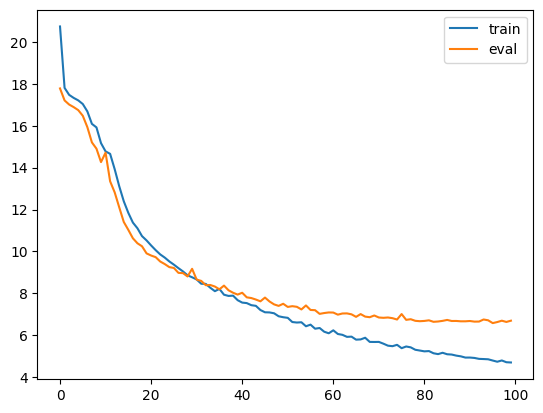

In [16]:
plt.plot(metrics["train_ppl"], label="train")
plt.plot(metrics["eval_ppl"], label="eval")
plt.legend(); plt.show()

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def predict_last(text, num_steps, vocab, model, device):
    state, outputs = None, [vocab[text[0]]]
    model.eval()
    with torch.no_grad():
        for i in range(num_steps+len(text)-1):
            if i < len(text) - 1:
                outputs.append(vocab[text[i+1]])
            else:
                logits, state = model(torch.tensor([[outputs[-1]]], device=device), state)
                pred_id = logits.argmax(dim=-1).reshape(1)
                outputs.append(int(pred_id))
        return ''.join(vocab.to_tokens(outputs))

def predict(text, num_steps, vocab, model, device):
    state, outputs = None, [vocab[text[0]]]
    model.eval()
    with torch.no_grad():
        for i in range(num_steps+len(text)-1):
            if i < len(text) - 1:
                outputs.append(vocab[text[i+1]])
            else:
                logits, state = model(torch.tensor([outputs], device=device), state)
                pred_id = logits.argmax(dim=-1).reshape(-1)
                outputs.append(int(pred_id[-1]))
        return ''.join(vocab.to_tokens(outputs))

In [18]:
predict_last("it has", 20, text_data.vocab, model, device=device)

'it has the time traveller '

In [19]:
predict("it has", 20, text_data.vocab, model, device=device)

'it has a mone a milation i'

In [20]:
class LSTM(nn.Module):
    def __init__(self, num_inputs, num_hiddens):
        super(LSTM, self).__init__()
        self.rnn = nn.LSTM(input_size=num_inputs, hidden_size=num_hiddens)
        self.num_hiddens = num_hiddens

    def forward(self, x, H_C=None):
        return self.rnn(x, H_C)

In [21]:
class RNNLM(nn.Module):
    def __init__(self, rnn, vocab_size):
        super(RNNLM, self).__init__()
        self.linear = nn.Linear(in_features=rnn.num_hiddens, out_features=vocab_size)
        self.vocab_size = vocab_size
        self.rnn = rnn

    def one_hot(self, x):
        return F.one_hot(x.T, self.vocab_size).type(torch.float32)

    def forward(self, x, state=None):
        embeds = self.one_hot(x)
        rnn_outputs, state = self.rnn(embeds, state)
        outputs = self.linear(rnn_outputs).swapaxes(0,1)
        return outputs, state

In [22]:
rnn = LSTM(405, 32)
rnn_lm = RNNLM(rnn, 405)
x = torch.ones((16,32)).type(torch.int64)
rnn_lm(x, None)[0].shape

torch.Size([16, 32, 405])

In [23]:
vocab_size = text_data.vocab_size
lstm = LSTM(num_inputs=vocab_size, num_hiddens=32)
model = RNNLM(rnn=lstm, vocab_size=vocab_size)
metrics = train_lstm(model, max_epochs=100, clip_val=1, lr=4, train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, report_every=10)

[0/100] train_loss: 2.97631, train_ppl: 19.82636
[0/100] eval_loss: 2.82987, eval_ppl: 16.94943
[10/100] train_loss: 2.39474, train_ppl: 10.98070
[10/100] eval_loss: 2.34475, eval_ppl: 10.43852
[20/100] train_loss: 2.14860, train_ppl: 8.57833
[20/100] eval_loss: 2.17405, eval_ppl: 8.81182
[30/100] train_loss: 1.97791, train_ppl: 7.22821
[30/100] eval_loss: 2.03522, eval_ppl: 7.67628
[40/100] train_loss: 1.86004, train_ppl: 6.42633
[40/100] eval_loss: 1.96956, eval_ppl: 7.19441
[50/100] train_loss: 1.75232, train_ppl: 5.76859
[50/100] eval_loss: 1.91360, eval_ppl: 6.79800
[60/100] train_loss: 1.64789, train_ppl: 5.19622
[60/100] eval_loss: 1.90594, eval_ppl: 6.75142
[70/100] train_loss: 1.61585, train_ppl: 5.03384
[70/100] eval_loss: 1.87660, eval_ppl: 6.55583
[80/100] train_loss: 1.54461, train_ppl: 4.68723
[80/100] eval_loss: 1.88736, eval_ppl: 6.62546
[90/100] train_loss: 1.52195, train_ppl: 4.58268
[90/100] eval_loss: 1.87151, eval_ppl: 6.52231


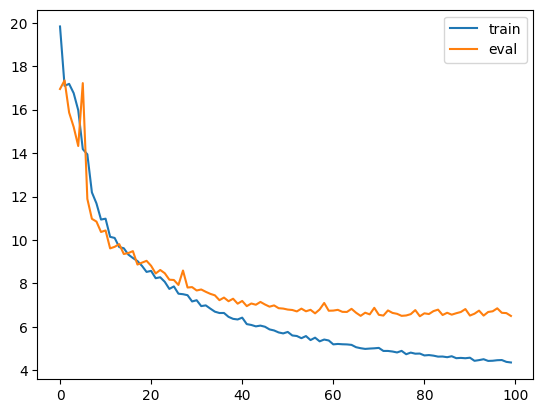

In [24]:
plt.plot(metrics["train_ppl"], label="train")
plt.plot(metrics["eval_ppl"], label="eval")
plt.legend(); plt.show()

In [25]:
predict_last("it has", 20, text_data.vocab, model, device=device)

'it has the time traveller '

In [26]:
predict("it has", 20, text_data.vocab, model, device=device)

'it has for and the time tr'